Paquete 'TPS.zip' detectado. Procesando base de datos...
Carga transaccional con segmentación profunda completada.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

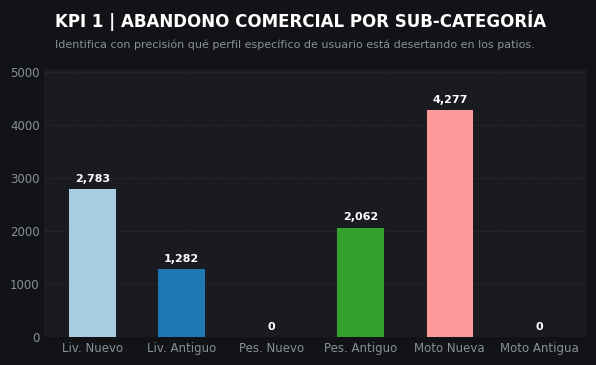

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

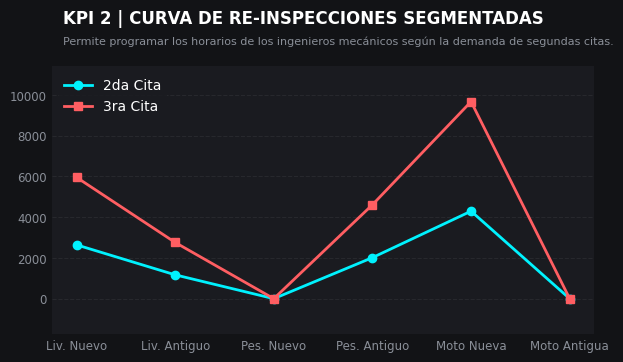

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

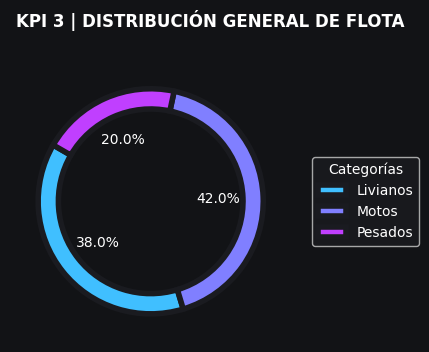

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

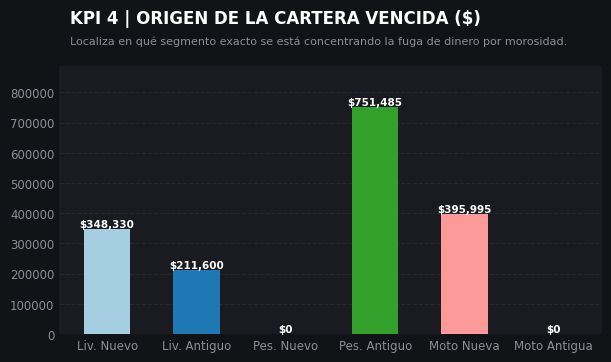

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

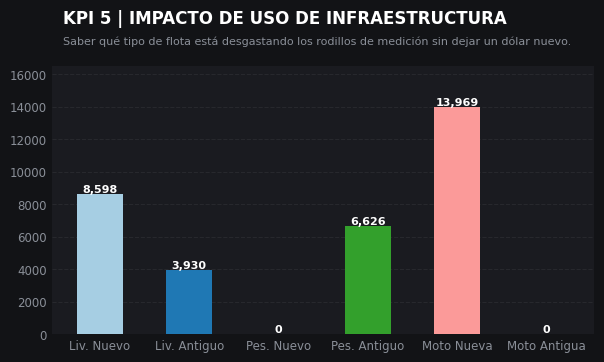

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

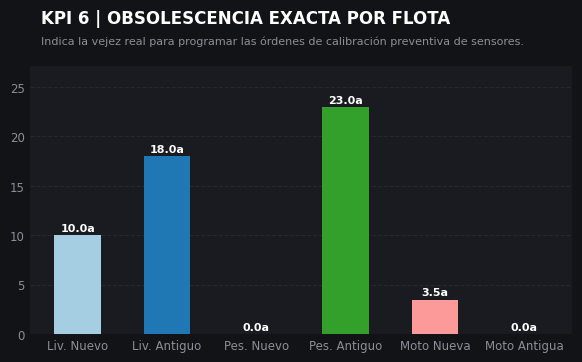

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

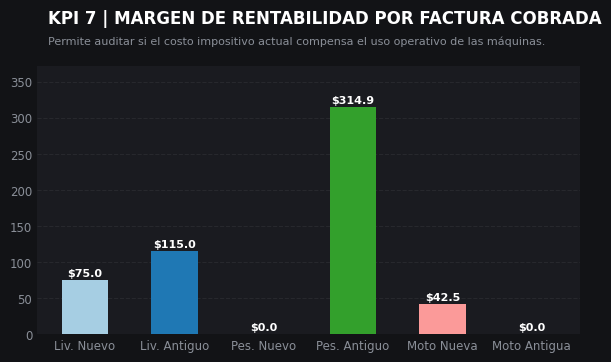

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

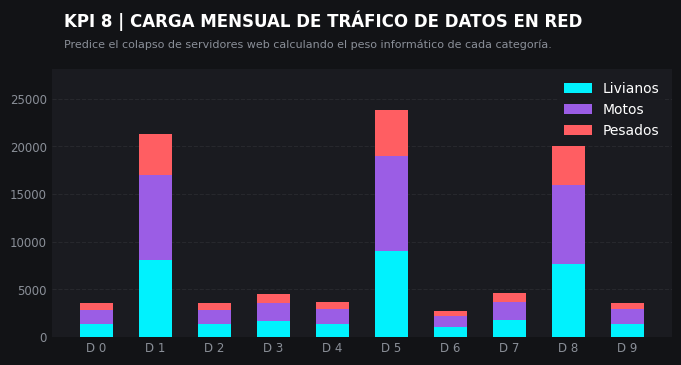

<IPython.core.display.Javascript object>

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import widgets
import zipfile
import os

# ============================================================
# 1. DESCOMPRESIÓN AUTOMÁTICA DEL ARCHIVO PAQUETE TPS.ZIP
# ============================================================
archivo_zip = "TPS.zip"
os.makedirs("data", exist_ok=True)

if os.path.exists(archivo_zip):
    print(f"Paquete '{archivo_zip}' detectado. Procesando base de datos...")
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Carga transaccional con segmentación profunda completada.\n")
else:
    raise FileNotFoundError(f"Sube el archivo '{archivo_zip}' en la barra lateral de Colab.")

ruta_vehiculos = "TPS/data/vehiculos.txt"
if not os.path.exists(ruta_vehiculos):
    ruta_vehiculos = "data/vehiculos.txt"

# ============================================================
# 2. INICIALIZACIÓN DE MATRICES Y ESTRUCTURAS DE SEGMENTACIÓN
# ============================================================
total_vehiculos = 0
sin_revision = 0
aprobado_2da = 0
aprobado_3ra = 0
conteo_livianos = 0
conteo_pesados = 0
conteo_motos = 0
recaudacion_real = 0.0
recaudacion_proyectada_total = 0.0

categorias = ["liviano_nuevo", "liviano_antiguo", "pesado_nuevo", "pesado_antiguo", "moto_nuevo", "moto_antiguo"]

# Estructuras analíticas por segmento
conteos_segmentados = {cat: 0 for cat in categorias}
antiguedad_segmentada = {cat: 0.0 for cat in categorias}
reinspecciones_segmentadas = {cat: 0 for cat in categorias}
recaudacion_segmentada = {cat: 0.0 for cat in categorias}
matriculados_segmentados = {cat: 0 for cat in categorias}
churn_segmentado = {cat: 0 for cat in categorias}
fuga_segmentada = {cat: 0.0 for cat in categorias}

# Reinspecciones abiertas por nivel de cita y segmento
citas_2da_segmentada = {cat: 0 for cat in categorias}
citas_3ra_segmentada = {cat: 0 for cat in categorias}

# Calendario impositivo cruzado por último dígito y tipo de flota
saturacion_placa_tipo = {i: {"liviano": 0, "pesado": 0, "moto": 0} for i in range(10)}

# ============================================================
# 3. PROCESAMIENTO ANALÍTICO INTEGRAL (ETL PROFUNDO)
# ============================================================
with open(ruta_vehiculos, "r") as archivo:
    for linea in archivo:
        linea = linea.strip()
        if not linea or len(linea.split(",")) < 9:
            continue

        datos = linea.split(",")
        try:
            placa = datos[1]
            anio = int(datos[3])
            tipo = datos[4]
            r1, r2, r3 = int(datos[6]), int(datos[7]), int(datos[8])
        except ValueError:
            continue

        total_vehiculos += 1
        es_matriculado = (r1 == 1 or r2 == 1 or r3 == 1)
        antiguedad_anios = 2026 - anio

        # Clasificación por segmento de edad (Límite directivo: 15 años)
        sufijo = "nuevo" if antiguedad_anios <= 15 else "antiguo"
        cat_clave = f"{tipo}_{sufijo}"

        if tipo == "liviano": conteo_livianos += 1
        elif tipo == "pesado": conteo_pesados += 1
        elif tipo == "moto": conteo_motos += 1

        if cat_clave in conteos_segmentados:
            conteos_segmentados[cat_clave] += 1
            antiguedad_segmentada[cat_clave] += antiguedad_anios

        # Auditoría de Citas e Ineficiencias (KPI 2)
        if not es_matriculado:
            sin_revision += 1
            churn_segmentado[cat_clave] += 1
        elif r2 == 1:
            aprobado_2da += 1
            citas_2da_segmentada[cat_clave] += 1
        elif r3 == 1:
            aprobado_3ra += 1
            citas_3ra_segmentada[cat_clave] += 1

        # Trabajo doble acumulado (KPI 5)
        if r2 == 1 or r3 == 1:
            reinspecciones_segmentadas[cat_clave] += 1

        # Reglas impositivas financieras (KPI 4 y KPI 7)
        tasa_base = 200.0 if tipo == "pesado" else 25.0
        valor_matricula = tasa_base + (antiguedad_anios * 5.0) + (0.0 if es_matriculado else 50.0)
        recaudacion_proyectada_total += valor_matricula

        if es_matriculado:
            recaudacion_real += valor_matricula
            matriculados_segmentados[cat_clave] += 1
            recaudacion_segmentada[cat_clave] += valor_matricula
        else:
            fuga_segmentada[cat_clave] += valor_matricula

        # Estrés de Red por calendario impositivo de placas (KPI 8)
        try:
            ultimo_digito = int(placa[-1])
            if tipo in saturacion_placa_tipo[ultimo_digito]:
                saturacion_placa_tipo[ultimo_digito][tipo] += 1
        except ValueError: continue

matriculados_totales = aprobado_2da + aprobado_3ra
tasa_churn = (sin_revision / total_vehiculos) * 100 if total_vehiculos > 0 else 0
fuga_dinero = max(0.0, recaudacion_proyectada_total - recaudacion_real)
total_reinspecciones = aprobado_2da + aprobado_3ra

# ============================================================
# 4. PARÁMETROS ESTÉTICOS DE LA INTERFAZ
# ============================================================
HEX_BG = '#121316'
HEX_CARD = '#1a1b20'
HEX_TEXT = '#ffffff'
HEX_MUTED = '#8a8f98'

PALETA_COMPLETA = sns.color_palette("Paired", 6)
COLOR_MINT = '#00b894'
COLOR_CORAL = '#ff5e62'
EJE_X_LABELS = ['Liv. Nuevo', 'Liv. Antiguo', 'Pes. Nuevo', 'Pes. Antiguo', 'Moto Nueva', 'Moto Antigua']

plt.style.use('dark_background')

def estilizar_tarjeta_ui(ax, titulo_kpi, subtitulo):
    ax.set_facecolor(HEX_CARD)
    fig = ax.get_figure()
    fig.patch.set_facecolor(HEX_BG)
    ax.text(0.02, 1.16, titulo_kpi, transform=ax.transAxes, fontsize=12, fontweight='bold', color=HEX_TEXT)
    ax.text(0.02, 1.08, subtitulo, transform=ax.transAxes, fontsize=8, color=HEX_MUTED)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=HEX_MUTED, labelsize=8.5, length=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.06, color=HEX_TEXT)
    ax.set_axisbelow(True)
    ax.margins(y=0.18)

# ============================================================
# 5. DESPLIEGUE POR PESTAÑAS INTERACTIVAS (TABBAR)
# ============================================================
tb = widgets.TabBar(['Dashboard', 'KPI 1', 'KPI 2', 'KPI 3', 'KPI 4', 'KPI 5', 'KPI 6', 'KPI 7', 'KPI 8'])

# --- DASHBOARD PRINCIPAL ---
with tb.output_to(0):
    print("="*75)
    print("  MIS DASHBOARD - OPERACIONES CON DESGLOSE ESTRATÉGICO ")
    print("="*75)
    print(f"  REGISTROS TOTALES     :  {total_vehiculos:,} vehículos procesados")
    print(f"  CLIENTES QUE SE VAN   :  {tasa_churn:.2f}% de abandono comercial")
    print("-"*75)
    print(f"   ÁREA               ¿QUÉ SIGNIFICA?                  VALOR")
    print("  ───────────────────────────────────────────────────────────────────────────")
    print(f"   DINERO REAL         Dinero que ya entró al banco       ${recaudacion_real:,.2f}")
    print(f"   DINERO PERDIDO      Cuentas que no se cobraron         ${fuga_dinero:,.2f}")
    print(f"   TRABAJO DOBLE       Citas repetidas por fallas         {total_reinspecciones:,} revisiones")
    print(f"   Northrop MOTOR      Cantidad total de motos revisadas  {conteo_motos:,} unidades")
    print("  ───────────────────────────────────────────────────────────────────────────")
    print("="*75)

# --- KPI 1 (RETENCIÓN PROFUNDA) ---
with tb.output_to(1):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    abandonos = [churn_segmentado[cat] for cat in categorias]
    barras = ax.bar(EJE_X_LABELS, abandonos, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (sin_revision*0.01), f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 1 | ABANDONO COMERCIAL POR SUB-CATEGORÍA", "Identifica con precisión qué perfil específico de usuario está desertando en los patios.")
    plt.show()

# --- KPI 2 (REINGRESOS SEPARADOS) ---
with tb.output_to(2):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    # Graficamos las segundas y terceras citas por segmento de forma apilada o paralela
    c2 = [citas_2da_segmentada[cat] for cat in categorias]
    c3 = [citas_3ra_segmentada[cat] for cat in categorias]

    ax.plot(EJE_X_LABELS, c2, marker='o', label='2da Cita', color='#00f2fe', linewidth=2)
    ax.plot(EJE_X_LABELS, c3, marker='s', label='3ra Cita', color='#ff5e62', linewidth=2)
    ax.legend(facecolor=HEX_CARD, edgecolor='none', labelcolor=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 2 | CURVA DE RE-INSPECCIONES SEGMENTADAS", "Permite programar los horarios de los ingenieros mecánicos según la demanda de segundas citas.")
    plt.show()

# --- KPI 3 (MANTENIDO GLOBAL PARA CAPEX) ---
with tb.output_to(3):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    plt.subplots_adjust(top=0.78, right=0.65)
    wedges, texts, autotexts = ax.pie([conteo_livianos, conteo_motos, conteo_pesados], labels=None, autopct='%1.1f%%', startangle=150, colors=sns.color_palette("cool", 3), wedgeprops=dict(width=0.18, edgecolor=HEX_CARD, linewidth=4))
    fig.patch.set_facecolor(HEX_BG)
    ax.set_facecolor(HEX_CARD)
    ax.text(0.02, 1.12, "KPI 3 | DISTRIBUCIÓN GENERAL DE FLOTA", transform=ax.transAxes, fontsize=12, fontweight='bold', color=HEX_TEXT)
    ax.legend(wedges, ['Livianos', 'Motos', 'Pesados'], title="Categorías", loc="center left", bbox_to_anchor=(1.05, 0.5), facecolor=HEX_CARD, labelcolor=HEX_TEXT)
    plt.show()

# --- KPI 4 (FUGA MONETARIA DETALLADA) ---
with tb.output_to(4):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    fugas = [fuga_segmentada[cat] for cat in categorias]
    barras = ax.bar(EJE_X_LABELS, fugas, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"${bar.get_height():,.0f}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=7.5)
    estilizar_tarjeta_ui(ax, "KPI 4 | ORIGEN DE LA CARTERA VENCIDA ($)", "Localiza en qué segmento exacto se está concentrando la fuga de dinero por morosidad.")
    plt.show()

# --- KPI 5 (TRABAJO DOBLE EN PLANTA) ---
with tb.output_to(5):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    valores_kpi5 = [reinspecciones_segmentadas[cat] for cat in categorias]
    barras = ax.bar(EJE_X_LABELS, valores_kpi5, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{int(bar.get_height()):,}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 5 | IMPACTO DE USO DE INFRAESTRUCTURA", "Saber qué tipo de flota está desgastando los rodillos de medición sin dejar un dólar nuevo.")
    plt.show()

# --- KPI 6 (EDADES PROMEDIO) ---
with tb.output_to(6):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    edades = [antiguedad_segmentada[cat] / conteos_segmentados[cat] if conteos_segmentados[cat] > 0 else 0 for cat in categorias]
    barras = ax.bar(EJE_X_LABELS, edades, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{bar.get_height():.1f}a", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 6 | OBSOLESCENCIA EXACTA POR FLOTA", "Indica la vejez real para programar las órdenes de calibración preventiva de sensores.")
    plt.show()

# --- KPI 7 (TICKET PROMEDIO ABIERTO) ---
with tb.output_to(7):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)
    tickets = [recaudacion_segmentada[cat] / matriculados_segmentados[cat] if matriculados_segmentados[cat] > 0 else 0 for cat in categorias]
    barras = ax.bar(EJE_X_LABELS, tickets, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"${bar.get_height():,.1f}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 7 | MARGEN DE RENTABILIDAD POR FACTURA COBRADA", "Permite auditar si el costo impositivo actual compensa el uso operativo de las máquinas.")
    plt.show()

# --- KPI 8 (ESTRÉS DE TRÁFICO POR FLOTA) ---
with tb.output_to(8):
    fig, ax = plt.subplots(figsize=(8, 4))
    plt.subplots_adjust(top=0.78)

    # Creamos barras apiladas por tipo de vehículo en cada dígito
    digitos = [f"D {i}" for i in range(10)]
    livi_p = [saturacion_placa_tipo[i]["liviano"] for i in range(10)]
    moto_p = [saturacion_placa_tipo[i]["moto"] for i in range(10)]
    pesa_p = [saturacion_placa_tipo[i]["pesado"] for i in range(10)]

    b1 = ax.bar(digitos, livi_p, label='Livianos', color='#00f2fe', width=0.55)
    b2 = ax.bar(digitos, moto_p, bottom=livi_p, label='Motos', color='#9b5de5', width=0.55)

    bottom_pesados = [livi_p[i] + moto_p[i] for i in range(10)]
    b3 = ax.bar(digitos, pesa_p, bottom=bottom_pesados, label='Pesados', color='#ff5e62', width=0.55)

    ax.legend(facecolor=HEX_CARD, edgecolor='none', labelcolor=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 8 | CARGA MENSUAL DE TRÁFICO DE DATOS EN RED", "Predice el colapso de servidores web calculando el peso informático de cada categoría.")
    plt.show()